In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Make project scripts importable
sys.path.append(os.path.abspath('..'))

from scripts import data_loader
from scripts.financial_analysis import FinancialAnalyzer


In [ ]:
# 1. Load and prepare news data (all stocks)
news_path = os.path.join('..', 'data', 'raw_analyst_ratings.csv')
news_df = data_loader.load_data(news_path)

# Normalize dates and clean text
news_df['date'] = pd.to_datetime(news_df['date'], utc=True, errors='coerce')
news_df = news_df.dropna(subset=['date', 'headline'])

news_df['date_only'] = news_df['date'].dt.date
news_df['headline'] = news_df['headline'].astype(str).str.strip()

news_df[['headline', 'date', 'date_only']].head()


,headline,date,date_only
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 14:30:54+00:00,2020-06-05
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 14:45:20+00:00,2020-06-03
2,71 Biggest Movers From Friday,2020-05-26 08:30:07+00:00,2020-05-26
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 16:45:06+00:00,2020-05-22
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 15:38:59+00:00,2020-05-22


In [3]:
# 2. Sentiment analysis with VADER and daily aggregation
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_compound(text: str) -> float:
    if pd.isna(text) or not str(text).strip():
        return 0.0
    scores = analyzer.polarity_scores(str(text))
    return scores['compound']

news_df['sentiment_score'] = news_df['headline'].apply(get_sentiment_compound)

# Aggregate to daily average sentiment
daily_sentiment = (
    news_df
    .groupby('date_only')['sentiment_score']
    .mean()
    .rename('avg_daily_sentiment')
    .reset_index()
)

daily_sentiment.head()



,date_only,avg_daily_sentiment
0,2020-05-22,0.048
1,2020-05-26,0.000
2,2020-06-03,0.000
3,2020-06-05,0.000


In [ ]:
# 3. Retrieve AAPL stock data and compute daily returns
start_date = daily_sentiment['date_only'].min().strftime('%Y-%m-%d')
end_date = daily_sentiment['date_only'].max().strftime('%Y-%m-%d')

fa = FinancialAnalyzer('AAPL', start_date=start_date, end_date=end_date)
price_df = fa.retrieve_data()
fa.calculate_metrics()  # adds Daily_Return
price_df = fa.data.copy()

price_df['date_only'] = price_df.index.date
price_df[['Close', 'Daily_Return']].head()



Fetching data for A...


[*********************100%***********************]  1 of 1 completed

Data loaded: 9 rows.


Price,Close,Daily_Return
Date,,
2020-05-22,81.821442,NaN
2020-05-26,82.928696,0.013533
2020-05-27,82.976830,0.000580
2020-05-28,83.467880,0.005918
2020-05-29,84.863983,0.016726


Merged observation count: 2
Not enough variation / samples to compute a stable Pearson correlation.
Pearson correlation between avg daily sentiment and 'A' (Agilent) daily returns: nan


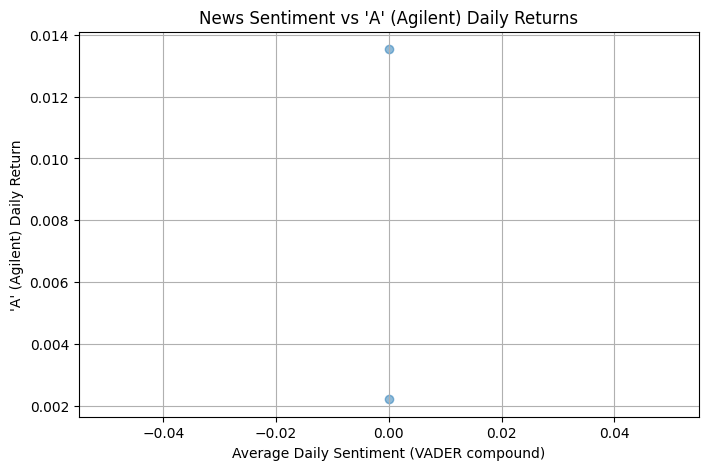

In [ ]:
# 4. Merge sentiment with returns and compute correlation
merged = pd.merge(
    daily_sentiment,
    price_df[['date_only', 'Daily_Return']],
    on='date_only',
    how='inner'
).dropna(subset=['avg_daily_sentiment', 'Daily_Return'])

print(f"Merged observation count: {len(merged)}")

# Pearson correlation between sentiment and returns
pearson_corr = merged['avg_daily_sentiment'].corr(merged['Daily_Return'])
print(f"Pearson correlation between avg daily sentiment and AAPL daily returns: {pearson_corr:.4f}")

# Simple scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(merged['avg_daily_sentiment'], merged['Daily_Return'], alpha=0.5)
plt.xlabel('Average Daily Sentiment (VADER compound)')
plt.ylabel('AAPL Daily Return')
plt.title('News Sentiment vs AAPL Daily Returns')
plt.grid(True)
plt.show()

